# Probability assesment of adverse weather conditions during a sporting event in Tallinn

The work includes data preparation, analysis of the probability of prolonged and significant precipitation/strong winds/combined conditions.

The following packages may be required for a successful run: `requests`, `pandas`, `urllib3`, `matplotlib`, `statsmodels`, and possibly `certifi`.

## 1. Data preparation

This analysis uses archived weather data from Open Meteo. This dataset includes only data for the city of Tallinn over the past 15 years (July 2010–July 2024). Since earlier data is more useful for potential assessments of weather pattern relationships, the timeframe for the selected data is significantly wider than the period (July 17–20)—**from July 1 to July 20**. Since the entire analysis may involve the relationship between weather patterns influencing atmospheric fronts, the following weather parameters were selected: **precipitation, wind speed, temperature, and atmospheric pressure**. 

First, it needs to obtain weather data for the city of Tallinn with the required interval and required weather parameters. Might be need to use `certifi`.

In [1]:
import requests
import pandas as pd
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def fetch_weather_data(year, latitude=59.437, longitude=24.753): # coordinates of Tallinn
    start_date = f"{year}-07-01"
    end_date = f"{year}-07-31" if year < 2024 else f"{year}-07-20"
    
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ["precipitation", "temperature_2m", "pressure_msl", "wind_speed_10m"],
        "timezone": "auto"
    }
    
    response = requests.get(url, params=params, verify=False)
    response.raise_for_status()
    data = response.json()
    
    hourly = data['hourly']
    df = pd.DataFrame({
        'datetime': pd.to_datetime(hourly['time']),
        'precipitation': hourly['precipitation'], # precipitation, mm/h
        'temperature': hourly['temperature_2m'], # temparature, °С
        'pressure': hourly['pressure_msl'], # pressure, hPa
        'wind_speed': hourly['wind_speed_10m'] # wind speed, m/s
    })
    df['year'] = year
    return df

# Cycle through all years
all_years = []
for year in range(2010, 2025):   # 2010..2024 
    print(f"Fetching {year}...")
    df_year = fetch_weather_data(year)
    all_years.append(df_year)

# Combine all years into one DataFrame
tln_weather = pd.concat(all_years, ignore_index=True)

print(tln_weather.head()) # first five rows
print(tln_weather.tail()) # last five rows

Fetching 2010...
Fetching 2011...
Fetching 2012...
Fetching 2013...
Fetching 2014...
Fetching 2015...
Fetching 2016...
Fetching 2017...
Fetching 2018...
Fetching 2019...
Fetching 2020...
Fetching 2021...
Fetching 2022...
Fetching 2023...
Fetching 2024...
             datetime  precipitation  temperature  pressure  wind_speed  year
0 2010-07-01 00:00:00            0.0         18.6    1013.2         9.4  2010
1 2010-07-01 01:00:00            0.0         17.7    1012.6        11.7  2010
2 2010-07-01 02:00:00            0.0         17.4    1012.2        13.4  2010
3 2010-07-01 03:00:00            0.0         17.0    1012.0        14.0  2010
4 2010-07-01 04:00:00            0.0         16.7    1011.6        14.4  2010
                 datetime  precipitation  temperature  pressure  wind_speed  \
10891 2024-07-20 19:00:00            0.9         17.5    1010.2        12.9   
10892 2024-07-20 20:00:00            0.0         17.7    1009.8         8.9   
10893 2024-07-20 21:00:00            0.0

In [3]:
# check how many rows dataset contain, it might be ~7200 rows
print("Shape:", tln_weather.shape)

Shape: (10896, 6)


Quite higher than 7200 rows. It looks like for all years except 2024, the data is from July 1st to July 31st (15 x 31 x 24 = 11160), and in 2024 it ends on July 20th. So only need to select the relevant data from the 1st to the 20th.

In [10]:
# create a copy
tln_weather_clean = tln_weather.copy()

# We leave only the days from July 1st to 20th.
tln_weather_clean = tln_weather_clean[tln_weather_clean['datetime'].dt.day <= 20]

In [11]:
# check how many rows dataset contain, it might be ~7200 rows
print("Shape:", tln_weather_clean.shape)

Shape: (7200, 6)


In [8]:
# Save as CSV
#tln_weather_clean.to_csv("C:/PythonGIS/dataanalysis/tln_weather_july_2010_2024.csv", index=False)

In [9]:
#import pandas as pd

In [12]:
#tln_weather = pd.read_csv("C:/PythonGIS/dataanalysis/tln_weather_july_2010_2024.csv")

In [14]:
# check table
tln_weather_clean.head(10)

,datetime,precipitation,temperature,pressure,wind_speed,year
0,2010-07-01 00:00:00,0.0,18.6,1013.2,9.4,2010
1,2010-07-01 01:00:00,0.0,17.7,1012.6,11.7,2010
2,2010-07-01 02:00:00,0.0,17.4,1012.2,13.4,2010
3,2010-07-01 03:00:00,0.0,17.0,1012.0,14.0,2010
4,2010-07-01 04:00:00,0.0,16.7,1011.6,14.4,2010
5,2010-07-01 05:00:00,0.0,16.4,1011.6,14.5,2010
6,2010-07-01 06:00:00,0.0,16.5,1011.5,14.5,2010
7,2010-07-01 07:00:00,0.0,17.2,1011.5,14.5,2010
8,2010-07-01 08:00:00,0.0,18.2,1011.3,15.9,2010
9,2010-07-01 09:00:00,0.0,19.4,1011.3,16.6,2010


For further analysis steps, separate date and time columns may be needed.

In [15]:
# Convert the 'datetime' column to datetime type (if it is not already in this format)
tln_weather_clean['datetime'] = pd.to_datetime(tln_weather_clean['datetime'])

In [16]:
# Create separate columns for date and time
tln_weather_clean['date'] = tln_weather_clean['datetime'].dt.date
tln_weather_clean['time'] = tln_weather_clean['datetime'].dt.time

print(tln_weather_clean[['datetime', 'date', 'time']].head(10))

             datetime        date      time
0 2010-07-01 00:00:00  2010-07-01  00:00:00
1 2010-07-01 01:00:00  2010-07-01  01:00:00
2 2010-07-01 02:00:00  2010-07-01  02:00:00
3 2010-07-01 03:00:00  2010-07-01  03:00:00
4 2010-07-01 04:00:00  2010-07-01  04:00:00
5 2010-07-01 05:00:00  2010-07-01  05:00:00
6 2010-07-01 06:00:00  2010-07-01  06:00:00
7 2010-07-01 07:00:00  2010-07-01  07:00:00
8 2010-07-01 08:00:00  2010-07-01  08:00:00
9 2010-07-01 09:00:00  2010-07-01  09:00:00


In [17]:
# delete unnessesary columns
tln_weather_clean = tln_weather_clean.drop(columns=['year'])

In [18]:
# Check the number of empty values for each column
print("Empty values for each column:")
print(tln_weather_clean.isnull().sum())

# Check the total number of empty values in the entire DataFrame
total_nan = tln_weather_clean.isnull().sum().sum()
print(f"\nAll empty values: {total_nan}")

Empty values for each column:
datetime         0
precipitation    0
temperature      0
pressure         0
wind_speed       0
date             0
time             0
dtype: int64

All empty values: 0


It is a clear dataset without none-values.

In [20]:
# Check data types
print(tln_weather_clean.dtypes)

datetime         datetime64[ns]
precipitation           float64
temperature             float64
pressure                float64
wind_speed              float64
date                     object
time                     object
dtype: object


## 2. Statistical analysis of adverse weather conditions

For first look of data create a descriptive table

In [22]:
print(tln_weather_clean[['precipitation', 'temperature', 'pressure', 'wind_speed']].describe())

       precipitation  temperature     pressure   wind_speed
count    7200.000000  7200.000000  7200.000000  7200.000000
mean        0.109083    17.857375  1011.378389    13.263611
std         0.407126     3.939648     6.628642     5.894453
min         0.000000     6.900000   989.100000     0.000000
25%         0.000000    14.900000  1007.000000     8.900000
50%         0.000000    17.500000  1011.900000    12.700000
75%         0.000000    20.300000  1016.100000    16.900000
max         8.500000    31.100000  1028.000000    42.100000


**First findings**: There's no precipitation in Tallinn for a significant portion of the time. This is shown by the 25th, 50th, and 75th percentiles—at least 75% of the hours in Tallinn are rainless. This is generally consistent with Estonian summer weather. As for strong winds (more than 10 m/s), in more than half of the cases the wind was strong.

Now look at event time dates.

In [23]:
# select only 17-20 July
df_event = tln_weather_clean[tln_weather_clean['datetime'].dt.day.between(17, 20)].copy()

In [25]:
print("Shape:", df_event.shape)

Shape: (1440, 7)


15 х 4 х 24 = 1440 rows. It looks ok.

In [26]:
print(df_event[['precipitation', 'temperature', 'pressure', 'wind_speed']].describe())

       precipitation  temperature     pressure   wind_speed
count    1440.000000  1440.000000  1440.000000  1440.000000
mean        0.071667    18.061389  1011.618056    13.350069
std         0.296076     3.477811     5.288630     5.505440
min         0.000000    11.300000   997.900000     0.700000
25%         0.000000    15.400000  1008.500000     9.200000
50%         0.000000    17.600000  1011.600000    13.000000
75%         0.000000    20.400000  1015.300000    17.000000
max         5.600000    28.600000  1022.000000    29.200000


Basicly same situation as for 1-20 July.

It's important for guests of honor to stay dry during the event, so light precipitation, which spectators might protect themselves from with an umbrella, is not included in the analysis. Perceptible precipitation of more than **1 mm/h** and lasting more than **three hours** is considered.

In [28]:
from statsmodels.stats.proportion import proportion_confint

The `has_long_rain` function determines whether there is at least one episode in a year's data where `rainy_hour == True` lasts for 3 or more consecutive hours.

In [35]:
threshold_rain = 1.0 # more than 1 mm/h
df_event['rainy_hour'] = df_event['precipitation'] >= threshold_rain

def has_long_rain(group):
    group = group.sort_values('datetime')
    group['block'] = (group['rainy_hour'] != group['rainy_hour'].shift()).cumsum()
    rain_blocks = group[group['rainy_hour']]
    block_lengths = rain_blocks.groupby('block').size()
    return 1 if (block_lengths >= 3).any() else 0 

yearly_rain = df_event.groupby(df_event['datetime'].dt.year).apply(has_long_rain)
prob_rain = yearly_rain.mean() 
ci_rain = proportion_confint(yearly_rain.sum(), len(yearly_rain), alpha=0.05, method='wilson') # for 95% confidence interval calculation

print(f"\nLong rain (≥{threshold_rain} mm/h, ≥3h)")
print(f"Probability of rain: {prob_rain:.1%} ({yearly_rain.sum()} years of {len(yearly_rain)})")
print(f"95% confidence interval: [{ci_rain[0]:.1%}, {ci_rain[1]:.1%}]")


Long rain (≥1.0 mm/h, ≥3h)
Probability of rain: 6.7% (1 years of 15)
95% confidence interval: [1.2%, 29.8%]


The average duration of one event is 3 hours per day, so it is important to find out whether there is a period of this length with strong winds.

Lets calculate same values for wind speed.

In [32]:
threshold_wind = 10.0  # m/s
df_event['windy_hour'] = df_event['wind_speed'] >= threshold_wind

def has_long_wind(group):
    group = group.sort_values('datetime')
    group['block'] = (group['windy_hour'] != group['windy_hour'].shift()).cumsum()
    wind_blocks = group[group['windy_hour']]
    block_lengths = wind_blocks.groupby('block').size()
    return 1 if (block_lengths >= 3).any() else 0

yearly_wind = df_event.groupby(df_event['datetime'].dt.year).apply(has_long_wind)
prob_wind = yearly_wind.mean()
ci_wind = proportion_confint(yearly_wind.sum(), len(yearly_wind), alpha=0.05, method='wilson')

print(f"Long strong wind (≥{threshold_wind} m/s, ≥3h): {prob_wind:.1%} ({yearly_wind.sum()} years of {len(yearly_wind)})")
print(f"95% CI: [{ci_wind[0]:.1%}, {ci_wind[1]:.1%}]")

Long strong wind (≥10.0 m/s, ≥3h): 100.0% (15 years of 15)
95% CI: [79.6%, 100.0%]


Strong winds alone aren't a valid reason to postpone an event. However, if a strong storm is accompanied by rain, then that's a good reason to purchase canopies or move the event indoors.

Lets calculate for combined conditions.

In [33]:
df_event['bad_weather'] = df_event['rainy_hour'] & df_event['windy_hour']

def has_long_bad(group):
    group = group.sort_values('datetime')
    group['block'] = (group['bad_weather'] != group['bad_weather'].shift()).cumsum()
    bad_blocks = group[group['bad_weather']]
    block_lengths = bad_blocks.groupby('block').size()
    return 1 if (block_lengths >= 3).any() else 0

yearly_bad = df_event.groupby(df_event['datetime'].dt.year).apply(has_long_bad)
prob_bad = yearly_bad.mean()
ci_bad = proportion_confint(yearly_bad.sum(), len(yearly_bad), alpha=0.05, method='wilson')

print(f"Combined (rain≥1.0 mm/h AND wind≥10 m/s, ≥3h): {prob_bad:.1%} ({yearly_bad.sum()} years of {len(yearly_bad)})")
print(f"95% CI: [{ci_bad[0]:.1%}, {ci_bad[1]:.1%}]")

Combined (rain≥1.0 mm/h AND wind≥10 m/s, ≥3h): 6.7% (1 years of 15)
95% CI: [1.2%, 29.8%]


However, four days is too short to fully understand the weather in midsummer in Estonia. Therefore, it's necessary to calculate not only the days of the event but also the entire selected period (July 1-20). Use the `tln_weather_clean`.

In [37]:
# Rain
threshold_rain = 1.0 # more than 1 mm/h
tln_weather_clean['rainy_hour'] = tln_weather_clean['precipitation'] >= threshold_rain

def has_long_rain(group):
    group = group.sort_values('datetime')
    group['block'] = (group['rainy_hour'] != group['rainy_hour'].shift()).cumsum()
    rain_blocks = group[group['rainy_hour']]
    block_lengths = rain_blocks.groupby('block').size()
    return 1 if (block_lengths >= 3).any() else 0 

yearly_rain = tln_weather_clean.groupby(tln_weather_clean['datetime'].dt.year).apply(has_long_rain)
prob_rain = yearly_rain.mean() 
ci_rain = proportion_confint(yearly_rain.sum(), len(yearly_rain), alpha=0.05, method='wilson') # for 95% confidence interval calculation

print(f"\nLong rain (≥{threshold_rain} mm/h, ≥3h)")
print(f"Probability of rain: {prob_rain:.1%} ({yearly_rain.sum()} years of {len(yearly_rain)})")
print(f"95% confidence interval: [{ci_rain[0]:.1%}, {ci_rain[1]:.1%}]")


# Wind
threshold_wind = 10.0  # m/s
tln_weather_clean['windy_hour'] = tln_weather_clean['wind_speed'] >= threshold_wind

def has_long_wind(group):
    group = group.sort_values('datetime')
    group['block'] = (group['windy_hour'] != group['windy_hour'].shift()).cumsum()
    wind_blocks = group[group['windy_hour']]
    block_lengths = wind_blocks.groupby('block').size()
    return 1 if (block_lengths >= 3).any() else 0

yearly_wind = tln_weather_clean.groupby(tln_weather_clean['datetime'].dt.year).apply(has_long_wind)
prob_wind = yearly_wind.mean()
ci_wind = proportion_confint(yearly_wind.sum(), len(yearly_wind), alpha=0.05, method='wilson')

print(f"\nLong strong wind (≥{threshold_wind} m/s, ≥3h): {prob_wind:.1%} ({yearly_wind.sum()} years of {len(yearly_wind)})")
print(f"95% CI: [{ci_wind[0]:.1%}, {ci_wind[1]:.1%}]")


# Rain + wind
tln_weather_clean['bad_weather'] = tln_weather_clean['rainy_hour'] & tln_weather_clean['windy_hour']

def has_long_bad(group):
    group = group.sort_values('datetime')
    group['block'] = (group['bad_weather'] != group['bad_weather'].shift()).cumsum()
    bad_blocks = group[group['bad_weather']]
    block_lengths = bad_blocks.groupby('block').size()
    return 1 if (block_lengths >= 3).any() else 0

yearly_bad = tln_weather_clean.groupby(tln_weather_clean['datetime'].dt.year).apply(has_long_bad)
prob_bad = yearly_bad.mean()
ci_bad = proportion_confint(yearly_bad.sum(), len(yearly_bad), alpha=0.05, method='wilson')

print(f"\nCombined (rain≥1.0 mm/h AND wind≥10 m/s, ≥3h): {prob_bad:.1%} ({yearly_bad.sum()} years of {len(yearly_bad)})")
print(f"95% CI: [{ci_bad[0]:.1%}, {ci_bad[1]:.1%}]")


Long rain (≥1.0 mm/h, ≥3h)
Probability of rain: 73.3% (11 years of 15)
95% confidence interval: [48.0%, 89.1%]

Long strong wind (≥10.0 m/s, ≥3h): 100.0% (15 years of 15)
95% CI: [79.6%, 100.0%]

Combined (rain≥1.0 mm/h AND wind≥10 m/s, ≥3h): 66.7% (10 years of 15)
95% CI: [41.7%, 84.8%]


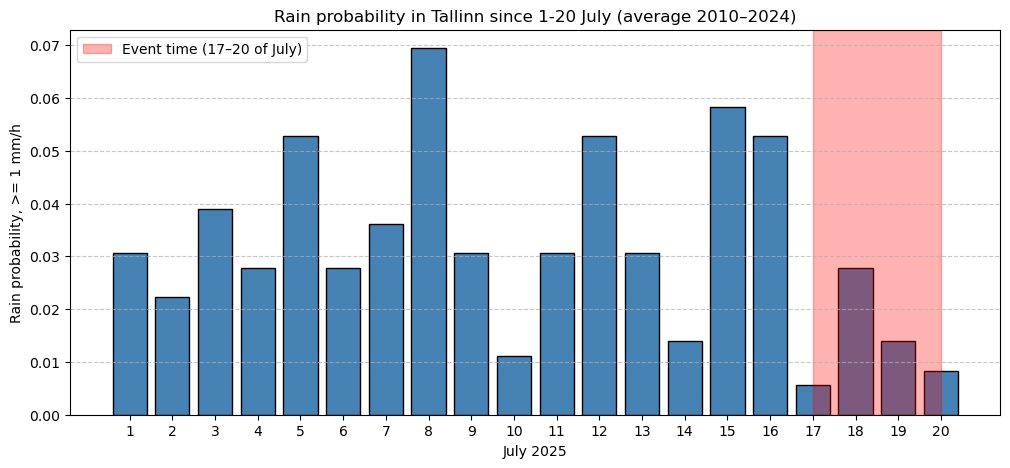

In [41]:
import matplotlib.pyplot as plt

daily_rain_prob = tln_weather_clean.groupby(tln_weather_clean['datetime'].dt.day).apply(
    lambda x: (x['precipitation'] >= 1.0).mean()
)

plt.figure(figsize=(12, 5))
plt.bar(daily_rain_prob.index, daily_rain_prob.values, color='steelblue', edgecolor='black')
plt.axvspan(17, 20, alpha=0.3, color='red', label='Event time (17–20 of July)')
plt.xlabel('July 2025')
plt.ylabel('Rain probability, >= 1 mm/h')
plt.title('Rain probability in Tallinn since 1-20 July (average 2010–2024)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(1, 21))  
plt.show()